# Creating a dendrogram displaying tool similarity

Based on the tools' heatmaps (not predictions) we calculate how similar the tools' results are and display those findings in a dendrogram

### Steps 

- Load in all heatmap data for the HGSOC experiment
- Reduce heatmap to comparing one modality against another (instead of all vs all)
- Fill empty / NaNs
- Make sure sample ordering is alphabetical and the same across tools
- Make each heatmap matrix into a vector
- Scale each heatmap so that 0 indicates a pair of samples is identical and 1 indicates they are very different
- Create array of observation vectors (i.e. matrix of tools x scaled heatmap values)
- Use scipy's linkage to perform hierarchical clustering on the array of observation vectors
- Use scipy's dendrogram for visualization

## Load & prep data

In [86]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

from analysis_shared_functions import load_heatmap_data

In [2]:
DATA_PATH = "/Users/lathouwe/Documents/HGSOC/hgsoc-reconstruction/benchmarking/data/output_data/vcf_update"

In [3]:
heatmap = load_heatmap_data(
    DATA_PATH=DATA_PATH,
    pseudobulk=False,
    tool="Vireo",
    dataset="hgsoc-new",
    ncells="null",
    rd=0,
    mod1="bulk_chunk_ribo",
    mod2="bulk_diss_polyA",
)

Processing tool Vireo, dataset hgsoc-new, read depth 0...


In [4]:
conpair_heatmap = load_heatmap_data(
    DATA_PATH=DATA_PATH,
    pseudobulk=False,
    tool="Conpair",
    dataset="hgsoc-new",
    ncells="null",
    rd=0,
    mod1="bulk_chunk_ribo",
    mod2="bulk_diss_polyA",
)

Processing tool Conpair, dataset hgsoc-new, read depth 0...


In [5]:
conpair_heatmap.columns = conpair_heatmap.columns.str.replace("_bulk_chunk_ribo", "", 1).str.replace("_bulk_diss_polyA", "", 1)
conpair_heatmap.index = conpair_heatmap.index.str.replace("_bulk_chunk_ribo", "", 1).str.replace("_bulk_diss_polyA", "", 1)


In [6]:
# Which sample is missing in the CrosscheckFingerprints heatmap
missing_samples = set(conpair_heatmap.columns) - set(heatmap.columns)
missing_samples

{'HGSOC-2018_bulk_chunk_ribo',
 'HGSOC-2023_bulk_chunk_ribo',
 'HGSOC-2094_bulk_chunk_ribo',
 'HGSOC-2126_bulk_chunk_ribo',
 'HGSOC-2129_bulk_chunk_ribo',
 'HGSOC-2186_bulk_chunk_ribo',
 'HGSOC-2202_bulk_chunk_ribo',
 'HGSOC-2209_bulk_chunk_ribo',
 'HGSOC-2216_bulk_chunk_ribo',
 'HGSOC-2221_bulk_chunk_ribo',
 'HGSOC-2230_bulk_chunk_ribo',
 'HGSOC-2238_bulk_chunk_ribo',
 'HGSOC-2240_bulk_chunk_ribo',
 'HGSOC-2246_bulk_chunk_ribo',
 'HGSOC-2249_bulk_chunk_ribo',
 'HGSOC-2268_bulk_chunk_ribo',
 'HGSOC-2278_bulk_chunk_ribo',
 'HGSOC-2296_bulk_chunk_ribo',
 'HGSOC-2309_bulk_chunk_ribo',
 'HGSOC-2313_bulk_chunk_ribo',
 'HGSOC-2364_bulk_chunk_ribo',
 'HGSOC-2401_bulk_chunk_ribo',
 'HGSOC-2407_bulk_chunk_ribo',
 'HGSOC-2408_bulk_chunk_ribo',
 'HGSOC-2416_bulk_chunk_ribo',
 'HGSOC-2423_bulk_chunk_ribo',
 'HGSOC-2430_bulk_chunk_ribo',
 'HGSOC-2444_bulk_chunk_ribo',
 'HGSOC-2455_bulk_chunk_ribo',
 'HGSOC-2460_bulk_chunk_ribo',
 'HGSOC-2466_bulk_chunk_ribo',
 'HGSOC-2477_bulk_chunk_ribo',
 'HGSOC-

In [7]:
print(heatmap.min().min(), heatmap.max().max())

0.0006028395693131 0.0085063203111877


In [4]:
# Keep only bulk_chunk_ribo samples in the rows and bulk_diss_polyA in the columns
heatmap = heatmap.loc[
    heatmap.index.str.contains("bulk_chunk_ribo"),
    heatmap.columns.str.contains("bulk_diss_polyA"),
]

In [5]:
heatmap

,HGSOC-2018_bulk_diss_polyA,HGSOC-2023_bulk_diss_polyA,HGSOC-2094_bulk_diss_polyA,HGSOC-2126_bulk_diss_polyA,HGSOC-2129_bulk_diss_polyA,HGSOC-2186_bulk_diss_polyA,HGSOC-2202_bulk_diss_polyA,HGSOC-2209_bulk_diss_polyA,HGSOC-2216_bulk_diss_polyA,HGSOC-2221_bulk_diss_polyA,...,HGSOC-2416_bulk_diss_polyA,HGSOC-2423_bulk_diss_polyA,HGSOC-2455_bulk_diss_polyA,HGSOC-2460_bulk_diss_polyA,HGSOC-2466_bulk_diss_polyA,HGSOC-2477_bulk_diss_polyA,HGSOC-2483_bulk_diss_polyA,HGSOC-2507_bulk_diss_polyA,HGSOC-2514_bulk_diss_polyA,HGSOC-2526_bulk_diss_polyA
HGSOC-2018_bulk_chunk_ribo,0.001487,0.001387,0.001315,0.001419,0.001633,0.001337,0.001350,0.001442,0.001392,0.001585,...,0.002118,0.001427,0.001500,0.001337,0.001284,0.004751,0.001564,0.001263,0.001428,0.001589
HGSOC-2023_bulk_chunk_ribo,0.001511,0.001365,0.001309,0.001416,0.001629,0.001330,0.001347,0.001438,0.001390,0.001579,...,0.002117,0.001423,0.001494,0.001333,0.001279,0.004794,0.001560,0.001258,0.001423,0.001580
HGSOC-2094_bulk_chunk_ribo,0.001060,0.000929,0.000846,0.000962,0.001175,0.000876,0.000892,0.000984,0.000934,0.001127,...,0.001665,0.000968,0.001039,0.000877,0.000824,0.004359,0.001109,0.000802,0.000966,0.001128
HGSOC-2126_bulk_chunk_ribo,0.001052,0.000923,0.000851,0.000890,0.001170,0.000872,0.000889,0.000978,0.000930,0.001120,...,0.001661,0.000964,0.001038,0.000874,0.000820,0.004334,0.001103,0.000798,0.000964,0.001127
HGSOC-2129_bulk_chunk_ribo,0.002370,0.002238,0.002169,0.002273,0.002406,0.002188,0.002205,0.002293,0.002246,0.002427,...,0.002967,0.002278,0.002345,0.002190,0.002138,0.005637,0.002421,0.002115,0.002279,0.002440
HGSOC-2186_bulk_chunk_ribo,0.000860,0.000730,0.000656,0.000762,0.000975,0.000663,0.000694,0.000784,0.000735,0.000927,...,0.001470,0.000768,0.000843,0.000680,0.000625,0.004192,0.000910,0.000603,0.000770,0.000931
HGSOC-2202_bulk_chunk_ribo,0.001101,0.000974,0.000901,0.001007,0.001221,0.000921,0.000929,0.001030,0.000982,0.001172,...,0.001713,0.001014,0.001088,0.000924,0.000870,0.004414,0.001153,0.000848,0.001015,0.001174
HGSOC-2209_bulk_chunk_ribo,0.001119,0.000994,0.000922,0.001025,0.001236,0.000940,0.000961,0.001051,0.000988,0.001188,...,0.001731,0.001030,0.001102,0.000944,0.000891,0.004402,0.001174,0.000869,0.001034,0.001198
HGSOC-2216_bulk_chunk_ribo,0.003012,0.002885,0.002815,0.002916,0.003114,0.002833,0.002852,0.002937,0.002888,0.002953,...,0.003602,0.002925,0.002996,0.002837,0.002784,0.006231,0.003067,0.002763,0.002923,0.003084
HGSOC-2221_bulk_chunk_ribo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
print(heatmap.min().min(), heatmap.max().max())

0.0006028395693131 0.0085063203111877


In [9]:
# Are there any missing values?
print(heatmap.isna().sum().sum())

128


In [12]:
crosscheck_max = heatmap.max().max()
crosscheck_min = heatmap.min().min()

In [13]:
scaled_heatmap = heatmap.apply(lambda x: (crosscheck_max - x) / (crosscheck_max - crosscheck_min))

In [14]:
# Verify that the scaled crosscheck heatmap has the expected range
print(scaled_heatmap.min().min(), scaled_heatmap.max().max())

0.0 1.0


In [15]:
# Convert df to numpy array
scaled_heatmap_numpy = scaled_heatmap.to_numpy()
crosscheck_vector = scaled_heatmap_numpy.reshape(-1)

In [16]:
crosscheck_vector

array([0.88807512, 0.90074037, 0.90984579, ..., 0.87529015, 0.85477277,
       0.83405923], shape=(1024,))

In [40]:

def create_scaled_heatmap_vector(tool, dataset, mod1, mod2, vector_size):
    heatmap = load_heatmap_data(
        DATA_PATH=DATA_PATH,
        pseudobulk=False,
        tool=tool,
        dataset=dataset,
        ncells="null",
        rd=0,
        mod1=mod1,
        mod2=mod2,
    )
    if heatmap is None:
        return np.full((vector_size,), 1)
    # Keep only mod1 samples in the rows and mod2 in the columns
    heatmap = heatmap.loc[
        heatmap.index.str.contains(mod1),
        heatmap.columns.str.contains(mod2),
    ]
    if tool == "Conpair":
        heatmap.columns = heatmap.columns.str.replace(f"_{mod1}", "", 1).str.replace(f"_{mod2}", "", 1)
        heatmap.index = heatmap.index.str.replace(f"_{mod1}", "", 1).str.replace(f"_{mod2}", "", 1)

    # Remove sample HGSOC-2507_bulk_diss_polyA (if present)
    if "HGSOC-2507_bulk_diss_polyA" in heatmap.index:
        heatmap = heatmap.drop(index="HGSOC-2507_bulk_diss_polyA")
    if "HGSOC-2507_bulk_diss_polyA" in heatmap.columns:
        heatmap = heatmap.drop(columns="HGSOC-2507_bulk_diss_polyA")

    heatmap_max = heatmap.max().max()
    heatmap_min = heatmap.min().min()
    if tool in ["Peddy", "TimeAttackGenComp", "Vireo"]:
        scaled_heatmap = heatmap.apply(lambda x: (x - heatmap_min) / (heatmap_max - heatmap_min))
    else:
        scaled_heatmap = heatmap.apply(lambda x: (heatmap_max - x) / (heatmap_max - heatmap_min))

    # Replace NaN values with 1
    scaled_heatmap = scaled_heatmap.fillna(1)
    # Flatten the scaled heatmap into a vector
    vector = scaled_heatmap.to_numpy().reshape(-1)

    return vector


In [63]:
crosscheck_vector = create_scaled_heatmap_vector("CrosscheckFingerprints", "hgsoc-new", "bulk_chunk_ribo", "bulk_diss_polyA")
crosscheck_vector

Processing tool CrosscheckFingerprints, dataset hgsoc-new, read depth 0...


array([0.39446557, 0.68785467, 0.75130679, ..., 0.68063098, 0.69482012,
       0.68445563], shape=(1116,))

In [64]:
conpair_vector = create_scaled_heatmap_vector("Conpair", "hgsoc-new", "bulk_chunk_ribo", "bulk_diss_polyA")
conpair_vector

Processing tool Conpair, dataset hgsoc-new, read depth 0...


array([0.03318113, 0.84687976, 0.86605784, ..., 0.93409437, 0.83150685,
       0.9391172 ], shape=(1116,))

In [20]:
hysys_vector = create_scaled_heatmap_vector("HYSYS", "hgsoc-new", "bulk_chunk_ribo", "bulk_diss_polyA")
hysys_vector

Processing tool HYSYS, dataset hgsoc-new, read depth 0...


array([0.41750842, 0.82154882, 0.80808081, ..., 0.84511785, 0.81818182,
       0.86868687], shape=(1116,))

In [18]:
ngscheckmate_vector = create_scaled_heatmap_vector("NGSCheckmate", "hgsoc-new", "bulk_chunk_ribo", "bulk_diss_polyA")
ngscheckmate_vector

Processing tool NGSCheckmate, dataset hgsoc-new, read depth 0...


array([0.2038835 , 0.66019417, 0.22330097, ..., 0.68932039, 0.44660194,
       0.51456311], shape=(1116,))

In [7]:
ntsm_vector = create_scaled_heatmap_vector("ntsm", "hgsoc-new", "bulk_chunk_ribo", "bulk_diss_polyA")
ntsm_vector

Processing tool ntsm, dataset hgsoc-new, read depth 0...


array([0.27851397, 1.        , 1.        , ..., 1.        , 1.        ,
       1.        ], shape=(1116,))

In [19]:
omicsprint_vector = create_scaled_heatmap_vector("OmicsPrint", "hgsoc-new", "bulk_chunk_ribo", "bulk_diss_polyA")
omicsprint_vector

Processing tool OmicsPrint, dataset hgsoc-new, read depth 0...


array([0.03707591, 0.6410793 , 0.62800036, ..., 0.87745908, 0.73938715,
              nan], shape=(1116,))

In [8]:
peddy_vector = create_scaled_heatmap_vector("Peddy", "hgsoc-new", "bulk_chunk_ribo", "bulk_diss_polyA")
peddy_vector

Processing tool Peddy, dataset hgsoc-new, read depth 0...


array([0.03598903, 0.34763511, 0.33474895, ..., 0.48431092, 0.38821074,
       0.54449487], shape=(1116,))

In [7]:
somalier_vector = create_scaled_heatmap_vector("Somalier", "hgsoc-new", "bulk_chunk_ribo", "bulk_diss_polyA")
somalier_vector

Processing tool Somalier, dataset hgsoc-new, read depth 0...


array([0.001, 0.311, 0.73 , ..., 0.867, 0.692, 0.916], shape=(1116,))

In [34]:
timeattack_vector = create_scaled_heatmap_vector("TimeAttackGenComp", "hgsoc-new", "bulk_chunk_ribo", "bulk_diss_polyA")
timeattack_vector

Processing tool TimeAttackGenComp, dataset hgsoc-new, read depth 0...
Could not find data for TimeAttackGenComp, real dataset hgsoc-new, read depth 0. 


array([1, 1, 1, ..., 1, 1, 1], shape=(1116,))

In [11]:
vireo_vector = create_scaled_heatmap_vector("Vireo", "hgsoc-new", "bulk_chunk_ribo", "bulk_diss_polyA")
vireo_vector

Processing tool Vireo, dataset hgsoc-new, read depth 0...


array([0.10941543, 0.09671439, 0.08758324, ..., 0.16119974, 0.14281188,
       0.16358395], shape=(1116,))

In [67]:
def create_observation_array(dataset, mod1, mod2):
    observation_array = []
    all_tools = [
        "Conpair",
        "CrosscheckFingerprints",
        "HYSYS",
        "NGSCheckmate",
        "ntsm",
        "OmicsPrint",
        "Peddy",
        "Somalier",
        # "TimeAttackGenComp",
        "Vireo"
    ]
    for tool in all_tools:
        tool_vector = create_scaled_heatmap_vector(tool, dataset, mod1, mod2, 1116)
        observation_array.append(tool_vector)
    return np.stack(observation_array)

In [76]:
obs_array = create_observation_array("hgsoc-new", "bulk_chunk_ribo", "bulk_diss_polyA")

Processing tool Conpair, dataset hgsoc-new, read depth 0...
Processing tool CrosscheckFingerprints, dataset hgsoc-new, read depth 0...
Processing tool HYSYS, dataset hgsoc-new, read depth 0...
Processing tool NGSCheckmate, dataset hgsoc-new, read depth 0...
Processing tool ntsm, dataset hgsoc-new, read depth 0...
Processing tool OmicsPrint, dataset hgsoc-new, read depth 0...
Processing tool Peddy, dataset hgsoc-new, read depth 0...
Processing tool Somalier, dataset hgsoc-new, read depth 0...
Processing tool Vireo, dataset hgsoc-new, read depth 0...


In [77]:
obs_array

array([[0.03318113, 0.84687976, 0.86605784, ..., 0.93409437, 0.83150685,
        0.9391172 ],
       [0.39446557, 0.68785467, 0.75130679, ..., 0.68063098, 0.69482012,
        0.68445563],
       [0.41750842, 0.82154882, 0.80808081, ..., 0.84511785, 0.81818182,
        0.86868687],
       ...,
       [0.03598903, 0.34763511, 0.33474895, ..., 0.48431092, 0.38821074,
        0.54449487],
       [0.001     , 0.311     , 0.73      , ..., 0.867     , 0.692     ,
        0.916     ],
       [0.10941543, 0.09671439, 0.08758324, ..., 0.16119974, 0.14281188,
        0.16358395]], shape=(9, 1116))

In [99]:
obs_array.shape

(9, 1116)

In [90]:
heatmap_distances = pdist(obs_array, metric="euclidean")
heatmap_distances

array([ 7.19472304,  4.34684707, 16.92410754,  4.44491484,  5.86636005,
       15.18371331,  8.65220742, 20.63091447,  5.41276976, 11.41552292,
       10.16940851,  6.02432084,  9.52669273,  6.41413162, 15.03956001,
       14.87840817,  6.29730029,  4.81594847, 13.48090846,  8.59360875,
       18.63593982, 19.80796417, 13.52018544,  8.40863735, 13.04090121,
       12.91428858,  8.71952407, 18.76322126, 12.22317069, 23.78604461,
       11.96156505,  7.27562849, 17.35908853,  9.74097259, 10.48141554,
       15.51217591])

In [89]:
heatmap_distances.shape

(36,)

In [100]:
Z = linkage(obs_array, method="average")
Z

array([[ 0.        ,  2.        ,  4.34684707,  2.        ],
       [ 5.        ,  9.        ,  5.34115426,  3.        ],
       [ 1.        , 10.        ,  6.21060455,  4.        ],
       [ 4.        , 11.        ,  7.40778693,  5.        ],
       [ 3.        ,  6.        ,  8.40863735,  2.        ],
       [ 7.        , 12.        ,  8.63174939,  6.        ],
       [ 8.        , 13.        , 11.69785206,  3.        ],
       [14.        , 15.        , 15.51154923,  9.        ]])

## Visualize scaling

In [71]:
all_tools = [
    "Conpair",
    "CrosscheckFingerprints",
    "HYSYS",
    "NGSCheckmate",
    "ntsm",
    "OmicsPrint",
    "Peddy",
    "Somalier",
    # "TimeAttackGenComp",
    "Vireo"
]

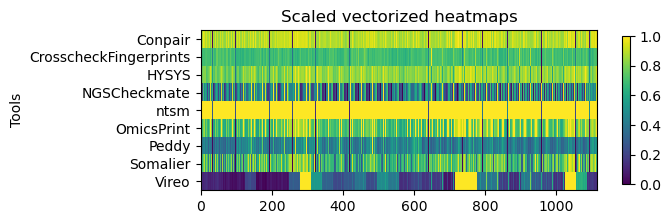

In [107]:
plt.imshow(obs_array, aspect=50, interpolation='nearest')
plt.colorbar(shrink=0.4)
plt.yticks(range(len(all_tools)), all_tools)
plt.title("Scaled vectorized heatmaps")
plt.ylabel("Tools")
plt.show()

## Dendrogram

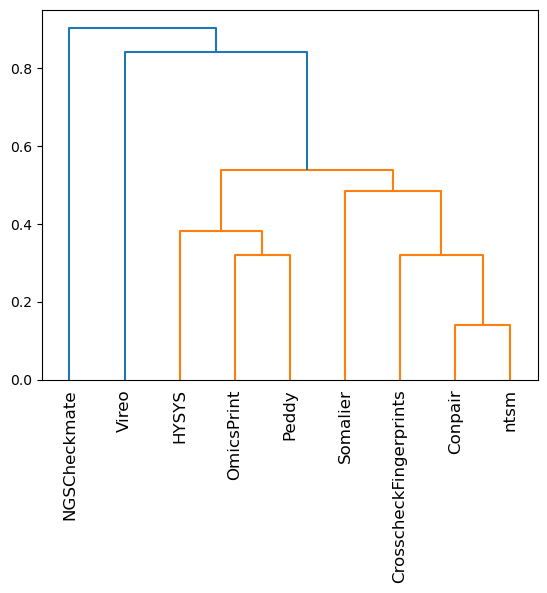

In [110]:
heatmap_distances = pdist(obs_array, metric="correlation")
linkage_matrix = linkage(heatmap_distances, method='average')
dendrogram(linkage_matrix, labels=all_tools, leaf_rotation=90)
plt.show()